In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("../data/raw/spotify-tracks-dataset.csv")
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])
df = df.dropna(subset=["track_name"])

features = ["danceability", "energy", "valence", "acousticness", "speechiness", "instrumentalness", "tempo"]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

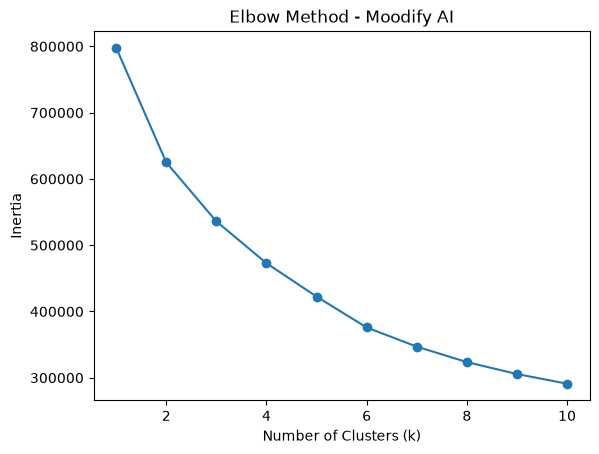

In [3]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Moodify AI")
plt.show()

In [4]:
diffs = [inertia_values[i] - inertia_values[i+1] for i in range(len(inertia_values)-1)]
diffs

[173081.4507354881,
 89004.42580982635,
 63044.90695641935,
 50406.37147590157,
 46619.234139516135,
 28853.28714030783,
 23373.04117621522,
 17985.138890711067,
 14592.530554659257]

In [5]:
for k in [4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, cluster_labels, sample_size=10000, random_state=42)
    print(f"k={k} -> Silhouette Score: {score:.4f}")

k=4 -> Silhouette Score: 0.2102
k=5 -> Silhouette Score: 0.2109


In [6]:
df["cluster_k4"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(scaled_features)
df["cluster_k5"] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(scaled_features)

cluster_summary_k4 = df.groupby("cluster_k4")[features].mean()
cluster_summary_k4

,danceability,energy,valence,acousticness,speechiness,instrumentalness,tempo
cluster_k4,,,,,,,
0,0.480899,0.799428,0.316319,0.070772,0.074454,0.223900,135.621583
1,0.681096,0.710815,0.685355,0.238027,0.070446,0.049668,119.267384
2,0.656780,0.665361,0.515320,0.377395,0.445359,0.031092,119.510532
3,0.462067,0.301419,0.305363,0.765604,0.047487,0.278491,109.651790


In [7]:
cluster_summary_k5 = df.groupby("cluster_k5")[features].mean()
cluster_summary_k5

,danceability,energy,valence,acousticness,speechiness,instrumentalness,tempo
cluster_k5,,,,,,,
0,0.473956,0.792625,0.373230,0.094082,0.075589,0.028139,138.733646
1,0.454415,0.288264,0.302496,0.786018,0.046882,0.259863,108.806284
2,0.690732,0.701487,0.688686,0.255610,0.072333,0.018868,116.611112
3,0.570695,0.752930,0.327462,0.100819,0.070670,0.788371,126.911827
4,0.652050,0.661817,0.513327,0.393075,0.466562,0.025893,119.223733


In [8]:
mood_map = {
    0: "Dark & Intense",
    1: "Energetic & Dance",
    2: "Speech-Heavy",
    3: "Calm & Acoustic"
}

df["mood"] = df["cluster_k4"].map(mood_map)

df["mood"].value_counts()

mood
Energetic & Dance    46517
Dark & Intense       35520
Calm & Acoustic      26405
Speech-Heavy          5557
Name: count, dtype: int64

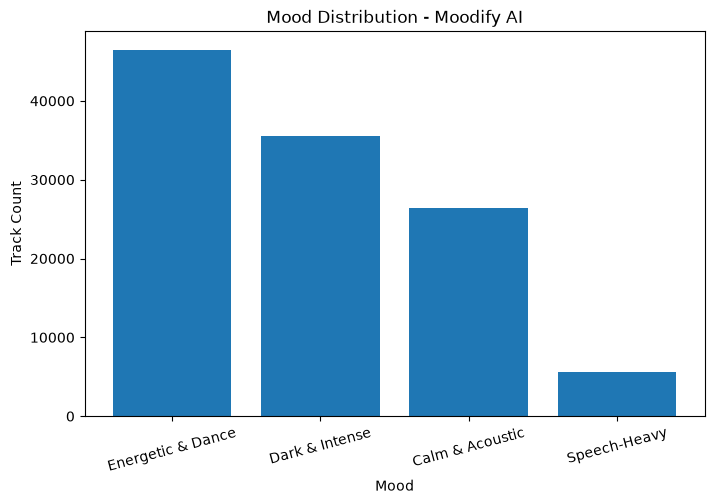

In [9]:
mood_counts = df["mood"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(mood_counts.index, mood_counts.values)
plt.xlabel("Mood")
plt.ylabel("Track Count")
plt.title("Mood Distribution - Moodify AI")
plt.xticks(rotation=15)
plt.show()